In [1]:
import tensorflow as tf 
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

I0000 00:00:1787134605.872018   21988 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787134605.904806   21988 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787134607.916816   21988 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# Normalize the pixel values to be between 0 and 1
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

# Convert the labels to one-hot encoding
train_labels = to_categorical(train_labels,10)
test_labels = to_categorical(test_labels,10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2372s 14us/step


Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 10)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 10)


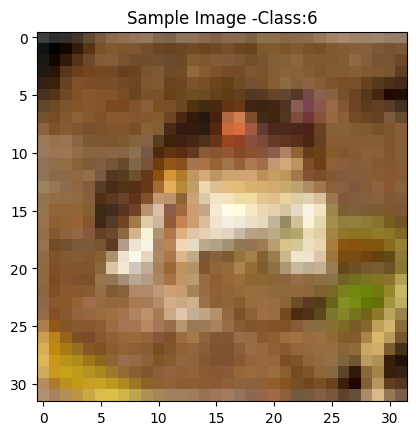

In [9]:
# Verify the data
print(f"Training data shape: {train_images.shape}") 
print(f"Training labels shape: {train_labels.shape}")
print(f"Test data shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")


# Visulalize a sample image

plt.imshow(train_images[0])
plt.title("Sample Image -Class:" + str(tf.argmax(train_labels[0]).numpy()))
# plt.axis('off')
plt.show()


In [10]:
from tensorflow.keras import layers, models
# Build the CNN model
def create_cnn_model():
    model = models.Sequential()
    #convolutional layer 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu',padding = 'same', input_shape=(32, 32, 3)))
    model.add(layers.MaxPooling2D((2, 2),strides = 2))
    #convolutional layer 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu',padding = 'same'))
    model.add(layers.MaxPooling2D((2, 2),strides = 2))
    #convolutional layer 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu',padding = 'same'))
    model.add(layers.MaxPooling2D((2, 2),strides = 2))
    # Flatten the output and add a fully connected layer
    model.add(layers.Flatten())
    # Fully connected layer
    model.add(layers.Dense(128, activation='relu'))
    # Dropout layer to prevent overfitting
    model.add(layers.Dropout(0.5))
    #output layer
    model.add(layers.Dense(10, activation='softmax'))
    return model    

cnn_model = create_cnn_model()

cnn_model.summary()

/home/bhoopender/tensorflow/tensorflow/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
cnn_model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [12]:
epochs = 50
batch_size = 64

history = cnn_model.fit(train_images, train_labels, epochs=epochs, batch_size=batch_size,
                        validation_split=0.2, verbose=1)

Epoch 1/50


I0000 00:00:1787138142.216113   22558 service.cc:153] XLA service 0x749000004100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787138142.216187   22558 service.cc:161]   StreamExecutor [0]: NVIDIA T1000, Compute Capability 7.5 (Driver: 13.2.0; Runtime: 12.5.0; Toolkit: 12.5.0; DNN: 9.25.0)
I0000 00:00:1787138142.236932   22558 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787138142.546818   22558 cuda_dnn.cc:461] Loaded cuDNN version 92500
I0000 00:00:1787138142.635903   22558 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2066__.44


 26/625 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1237 - loss: 2.2916

I0000 00:00:1787138146.803165   22558 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.3826 - loss: 1.6778 - val_accuracy: 0.5093 - val_loss: 1.3614
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5167 - loss: 1.3470 - val_accuracy: 0.5960 - val_loss: 1.1615
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5817 - loss: 1.1845 - val_accuracy: 0.6396 - val_loss: 1.0248
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6313 - loss: 1.0631 - val_accuracy: 0.6720 - val_loss: 0.9345
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6605 - loss: 0.9786 - val_accuracy: 0.6869 - val_loss: 0.9033
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6846 - loss: 0.9065 - val_accuracy: 0.7007 - val_loss: 0.8674
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7056 - loss: 0.8481 - val_accuracy: 0.7149 - val_loss: 0.8243
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7227 - loss: 0.7902 - val_accuracy: 0.7303 - val

In [13]:
test_loss, test_acc = cnn_model.evaluate(test_images, test_labels, verbose=2)
print(f"Test accuracy: {test_acc*100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

313/313 - 1s - 4ms/step - accuracy: 0.7349 - loss: 1.5680
Test accuracy: 73.49%
Test loss: 1.5680


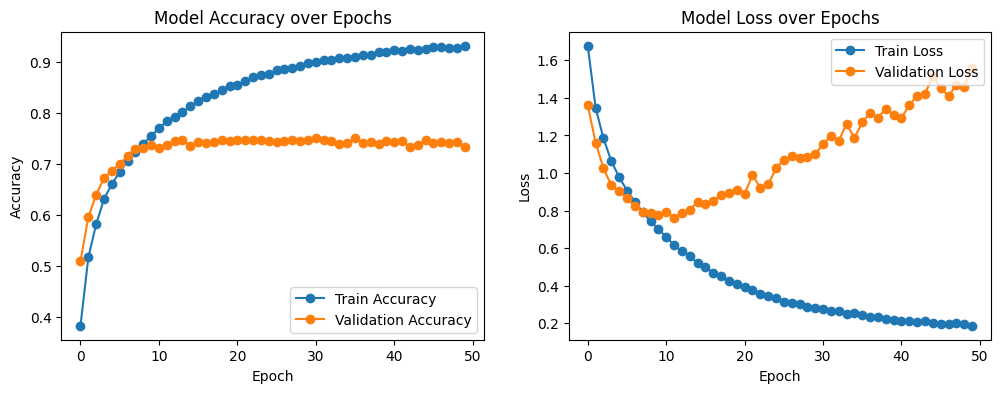

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],label='Train Accuracy',marker='o')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy',marker='o')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],label='Train Loss',marker='o')
plt.plot(history.history['val_loss'],label='Validation Loss',marker='o')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.show()

In [18]:
# saving the model to disk

model_save_path = 'cnn_cifar10_model.h5'

cnn_model.save(model_save_path)
print(f"Model saved to {model_save_path}")


Model saved to cnn_cifar10_model.h5


In [19]:
loaded_model = tf.keras.models.load_model(model_save_path)
print("Model Loaded sucessfully")

Model Loaded sucessfully


In [20]:
loaded_test_loss,loaded_test_accuracy = loaded_model.evaluate(test_images,test_labels,verbose=2)

print(f"Loaded model test Accuracy : {loaded_test_accuracy*100:.2f}%")

313/313 - 1s - 4ms/step - accuracy: 0.7349 - loss: 1.5680
Loaded model test Accuracy : 73.49%


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7349 - loss: 1.5680

Test Loss     : 1.5680
Test Accuracy : 0.7349
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


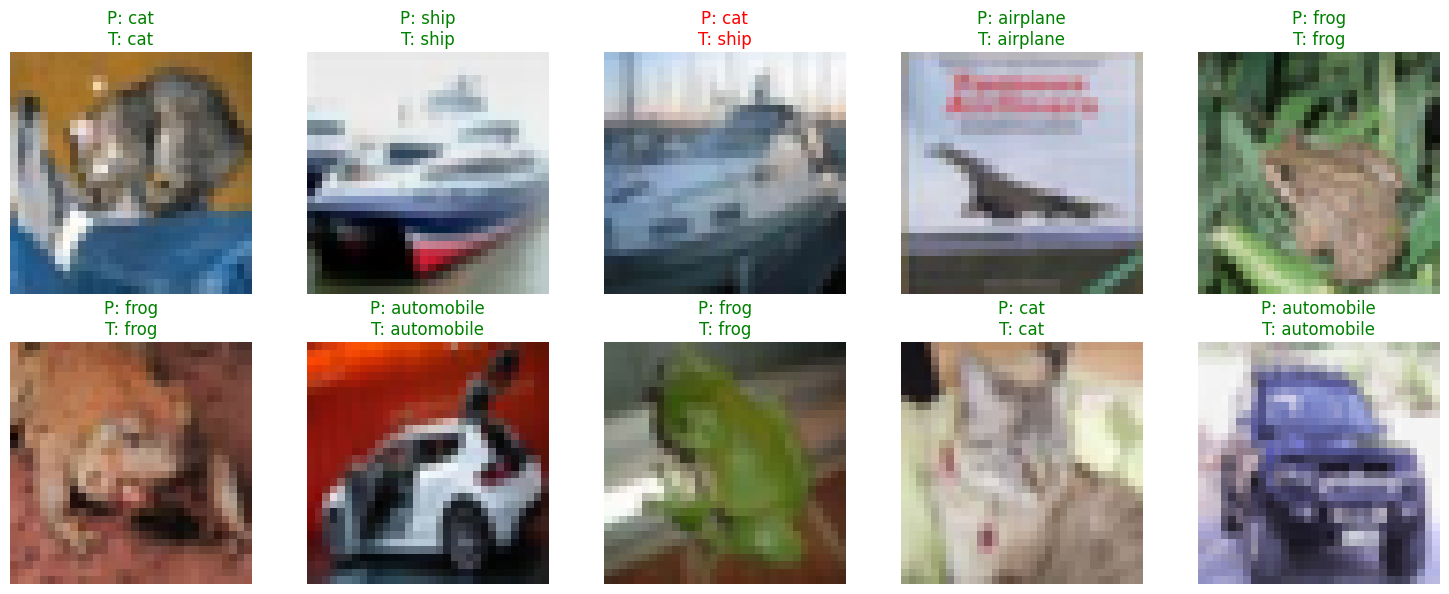

In [22]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical

# Load the trained model
model = tf.keras.models.load_model("cnn_cifar10_model.h5")

# Load CIFAR-10 dataset
(_, _), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# Normalize images
test_images = test_images.astype("float32") / 255.0

# One-hot encode labels (same as during training)
test_labels = to_categorical(test_labels, 10)

# CIFAR-10 class names
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

# Evaluate model
loss, accuracy = model.evaluate(test_images, test_labels, verbose=1)

print(f"\nTest Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f}")

# Predict on test set
predictions = model.predict(test_images, verbose=1)

# Convert probabilities to class indices
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_labels, axis=1)

# Display first 10 predictions
plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(test_images[i])
    plt.axis("off")

    pred = class_names[predicted_labels[i]]
    true = class_names[true_labels[i]]

    color = "green" if pred == true else "red"

    plt.title(f"P: {pred}\nT: {true}", color=color)

plt.tight_layout()
plt.show()